# 🚀 Lunar Lander — Deep Q-Network Agent

A **DQN (Deep Q-Network)** agent that learns to land a spacecraft on the moon using reinforcement learning.

Built with **PyTorch** and **Gymnasium**, visualized with **Plotly Express**.

---

## Table of Contents
1. **Setup** — Install dependencies & configure environment
2. **Domain Model** — Understand the problem space
3. **Architecture** — Q-Network, Replay Buffer, DQN Agent
4. **Baseline** — Random agent benchmark
5. **Training** — Train the DQN agent
6. **Analysis** — Training curves & dashboards
7. **Evaluation** — Test the trained agent
8. **Demo** — Record & display agent videos

## 1. Setup
Install required packages. `gymnasium[box2d]` provides the LunarLander environment with physics simulation.

In [0]:
%pip install gymnasium swig --quiet
dbutils.library.restartPython()
# %pip install box2d-py plotly imageio[ffmpeg] pandas --quiet
# dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%pip install gymnasium[box2d] --upgrade plotly imageio[ffmpeg] pandas --quiet
dbutils.library.restartPython()

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pmdarima 2.1.1 requires statsmodels>=0.14.5, but you have statsmodels 0.14.4 which is incompatible.
ydata-profiling 4.16.1 requires pandas!=1.4.0,<3.0,>1.1, but you have pandas 3.0.2 which is incompatible.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import gymnasium as gym
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import json
import os
import imageio
from collections import deque, namedtuple
from datetime import datetime
from zoneinfo import ZoneInfo
import base64
from IPython.display import HTML, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# ── Output path — update to your workspace ──
WORKSPACE_PATH = "./output"
os.makedirs(WORKSPACE_PATH, exist_ok=True)
print(f"Output directory: {WORKSPACE_PATH}")

Using device: cuda
Output directory: ./output


## 2. Domain Model — The Lunar Lander Problem

The [LunarLander-v3](https://gymnasium.farama.org/environments/box2d/lunar_lander/) environment simulates landing a spacecraft between two flags on the moon's surface.

### State Space (what the agent observes)
The agent receives **8 continuous values** each timestep:

| Index | Feature | Description |
|-------|---------|-------------|
| 0 | x position | Horizontal position |
| 1 | y position | Vertical position (altitude) |
| 2 | x velocity | Horizontal speed |
| 3 | y velocity | Vertical speed (descent rate) |
| 4 | angle | Tilt of the lander |
| 5 | angular velocity | Rotation speed |
| 6 | left leg contact | Boolean: left leg touching ground |
| 7 | right leg contact | Boolean: right leg touching ground |

### Action Space (what the agent can do)
**4 discrete actions:**
- `0` — Do nothing (coast)
- `1` — Fire left engine (push right)
- `2` — Fire main engine (push up)
- `3` — Fire right engine (push left)

### Reward Structure
- **+100 to +140** for landing on the pad
- **+10** for each leg making contact
- **-0.3** per frame for main engine firing
- **-0.03** per frame for side engine firing
- **-100** for crashing
- **Solved** when average reward >= 200 over 100 consecutive episodes

### Why DQN and not PPO?
In our MiniGrid project we used **PPO** because we had image-based observations (high-dimensional CNN input) and needed policy gradients.
Here the state is just **8 numbers** — DQN is simpler, faster to train, and converges well on low-dimensional discrete action spaces.

In [0]:
env = gym.make("LunarLander-v3")
state, info = env.reset(seed=SEED)

print("LunarLander-v3 Environment")
print("=" * 45)
print(f"State space:  {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"\nSample initial state:")
labels = ["x_pos", "y_pos", "x_vel", "y_vel", "angle", "ang_vel", "left_leg", "right_leg"]
for label, val in zip(labels, state):
    print(f"  {label:>12s}: {val:>8.4f}")
env.close()

LunarLander-v3 Environment
State space:  Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)

Sample initial state:
         x_pos:   0.0023
         y_pos:   1.4181
         x_vel:   0.2326
         y_vel:   0.3205
         angle:  -0.0027
       ang_vel:  -0.0527
      left_leg:   0.0000
     right_leg:   0.0000


## 3. Architecture

### 3.1 Q-Network
A feedforward neural network that takes the 8-dimensional state and outputs a Q-value for each of the 4 actions.

```
State (8) → Linear(128) → ReLU → Linear(128) → ReLU → Q-values (4)
```

**Analogy:** Think of the Q-Network as the agent's *landing intuition*. Given where it is and how fast it's moving, it estimates how valuable each thruster action would be. Early in training this intuition is random — over time it learns that firing the main engine when descending too fast is valuable.

In [0]:
class QNetwork(nn.Module):
    """Neural network that approximates Q-values for each action."""

    def __init__(self, state_size: int, action_size: int, hidden_sizes: list = [128, 128]):
        super(QNetwork, self).__init__()
        layers = []
        prev_size = state_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            prev_size = h
        layers.append(nn.Linear(prev_size, action_size))
        self.network = nn.Sequential(*layers)

    def forward(self, state):
        return self.network(state)

# Verify architecture
test_net = QNetwork(8, 4)
test_input = torch.randn(1, 8)
test_output = test_net(test_input)
print(f"Input shape:  {test_input.shape}  (batch=1, state_dim=8)")
print(f"Output shape: {test_output.shape}  (batch=1, actions=4)")
print(f"Q-values:     {test_output.detach().numpy().round(3)}")
print(f"Parameters:   {sum(p.numel() for p in test_net.parameters()):,}")
del test_net, test_input, test_output

Input shape:  torch.Size([1, 8])  (batch=1, state_dim=8)
Output shape: torch.Size([1, 4])  (batch=1, actions=4)
Q-values:     [[ 0.054 -0.022 -0.088  0.209]]
Parameters:   18,180


### 3.2 Experience Replay Buffer

Stores past `(state, action, reward, next_state, done)` transitions. During training, we sample **random batches** from this buffer instead of learning from consecutive transitions.

**Why?** Consecutive transitions are highly correlated (the lander doesn't teleport between frames). Learning from correlated data causes the network to overfit to recent patterns. Random sampling breaks this correlation — same principle we used in MiniGrid to prevent the agent from only learning about the last door it crossed.

In [0]:
Experience = namedtuple("Experience", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    """Fixed-size circular buffer storing (s, a, r, s', done) tuples."""

    def __init__(self, capacity: int = 100_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Experience(state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states = torch.FloatTensor(np.array([e.state for e in batch])).to(device)
        actions = torch.LongTensor([e.action for e in batch]).to(device)
        rewards = torch.FloatTensor([e.reward for e in batch]).to(device)
        next_states = torch.FloatTensor(np.array([e.next_state for e in batch])).to(device)
        dones = torch.FloatTensor([e.done for e in batch]).to(device)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

print(f"ReplayBuffer ready (capacity: 100,000 transitions)")

ReplayBuffer ready (capacity: 100,000 transitions)


### 3.3 DQN Agent

The full agent combines three key ideas:

| Component | What it does | Why it matters |
|-----------|-------------|----------------|
| **Experience Replay** | Learns from shuffled past experiences | Breaks temporal correlation |
| **Target Network** | Slowly-updated copy of Q-network | Stabilizes the moving target in the Bellman equation |
| **Epsilon-Greedy** | Random actions with probability ε | Balances exploration vs exploitation |

**Epsilon schedule:** starts at 1.0 (fully random) and decays by 0.5% per episode down to 0.01 — similar to how we tuned entropy coefficients in MiniGrid PPO, but simpler.

In [0]:
class DQNAgent:
    """DQN Agent with Experience Replay, Target Network, and Epsilon-Greedy exploration."""

    def __init__(
        self,
        state_size: int = 8,
        action_size: int = 4,
        lr: float = 5e-4,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.01,
        epsilon_decay: float = 0.995,
        batch_size: int = 64,
        buffer_capacity: int = 100_000,
        target_update_freq: int = 10,
        hidden_sizes: list = [128, 128],
    ):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq

        self.q_network = QNetwork(state_size, action_size, hidden_sizes).to(device)
        self.target_network = QNetwork(state_size, action_size, hidden_sizes).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        self.replay_buffer = ReplayBuffer(buffer_capacity)

        self.training_step = 0
        self.episode_count = 0
        self.losses = []

    def select_action(self, state, evaluate=False):
        if not evaluate and random.random() < self.epsilon:
            return random.randrange(self.action_size)
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        return q_values.argmax(dim=1).item()

    def store_experience(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)

    def learn(self):
        if len(self.replay_buffer) < self.batch_size:
            return 0.0
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(dim=1)[0]
            target_q_values = rewards + self.gamma * next_q_values * (1 - dones)
        loss = self.loss_fn(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), max_norm=1.0)
        self.optimizer.step()
        self.training_step += 1
        loss_val = loss.item()
        self.losses.append(loss_val)
        return loss_val

    def update_target_network(self):
        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
        self.episode_count += 1

    def save(self, path):
        torch.save({
            "q_network": self.q_network.state_dict(),
            "target_network": self.target_network.state_dict(),
            "optimizer": self.optimizer.state_dict(),
            "epsilon": self.epsilon,
            "episode_count": self.episode_count,
            "training_step": self.training_step,
        }, path)
        print(f"Model saved -> {path}")

    def load(self, path):
        checkpoint = torch.load(path, weights_only=True)
        self.q_network.load_state_dict(checkpoint["q_network"])
        self.target_network.load_state_dict(checkpoint["target_network"])
        self.optimizer.load_state_dict(checkpoint["optimizer"])
        self.epsilon = checkpoint["epsilon"]
        self.episode_count = checkpoint["episode_count"]
        self.training_step = checkpoint["training_step"]
        print(f"Model loaded <- {path} (episode {self.episode_count})")

print("DQNAgent ready.")

DQNAgent ready.


## 4. Random Agent Baseline

Before training, let's see how a completely random agent performs. This gives us the **floor** — any learning should beat this.
A random agent just fires thrusters randomly and almost always crashes. Expect scores around **-150 to -200**.

In [0]:
env = gym.make("LunarLander-v3")
random_rewards = []

for ep in range(100):
    state, _ = env.reset()
    total_reward = 0
    done = False
    while not done:
        action = env.action_space.sample()
        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        done = terminated or truncated
    random_rewards.append(total_reward)

env.close()

print(f"Random Agent Baseline (100 episodes):")
print(f"  Avg Reward:  {np.mean(random_rewards):.1f} +/- {np.std(random_rewards):.1f}")
print(f"  Min / Max:   {min(random_rewards):.1f} / {max(random_rewards):.1f}")

fig = px.histogram(
    x=random_rewards, nbins=30,
    title="Random Agent — Reward Distribution (Baseline)",
    labels={"x": "Episode Reward", "y": "Count"},
    color_discrete_sequence=["#EF553B"],
)
fig.add_vline(x=200, line_dash="dash", line_color="green", annotation_text="Solved (200)")
fig.update_layout(template="plotly_white", height=400)
fig.show()

Random Agent Baseline (100 episodes):
  Avg Reward:  -188.3 +/- 119.6
  Min / Max:   -483.9 / 34.6


## 5. Training

### Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Learning rate | 5e-4 | Standard for DQN on this environment |
| Gamma (discount) | 0.99 | Future rewards matter a lot for landing |
| Epsilon decay | 0.995 | ~1000 episodes from exploration to exploitation |
| Batch size | 64 | Good balance of speed and stability |
| Buffer capacity | 100K | Enough diversity without memory issues |
| Target update | Every 10 episodes | Hard update frequency |
| Hidden layers | 128 x 128 | Sufficient for 8-dim state |
| Gradient clip | 1.0 | Prevents exploding gradients from early crash experiences |

Training should solve (200+ avg reward) in roughly **500-700 episodes**.

In [0]:
NUM_EPISODES = 1000
MAX_STEPS = 1000
LOG_EVERY = 50

agent = DQNAgent(
    state_size=8, action_size=4,
    lr=5e-4, gamma=0.99,
    epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995,
    batch_size=64, buffer_capacity=100_000,
    target_update_freq=10, hidden_sizes=[128, 128],
)

print(f"Agent initialized. Training for {NUM_EPISODES} episodes...")

Agent initialized. Training for 1000 episodes...


In [0]:
env = gym.make("LunarLander-v3")

all_rewards = []
all_lengths = []
all_epsilons = []
best_avg_reward = -float("inf")
solved_episode = None

print(f"{'='*65}")
print(f"  Starting Training — {NUM_EPISODES} episodes")
print(f"{'='*65}\n")

for episode in range(1, NUM_EPISODES + 1):
    state, _ = env.reset()
    total_reward = 0
    steps = 0

    for step in range(MAX_STEPS):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.store_experience(state, action, reward, next_state, done)
        agent.learn()

        state = next_state
        total_reward += reward
        steps += 1
        if done:
            break

    agent.decay_epsilon()
    all_rewards.append(total_reward)
    all_lengths.append(steps)
    all_epsilons.append(agent.epsilon)

    if episode % agent.target_update_freq == 0:
        agent.update_target_network()

    last_100 = all_rewards[-100:]
    avg_reward = np.mean(last_100)

    if avg_reward > best_avg_reward and episode >= 100:
        best_avg_reward = avg_reward
        agent.save(f"{WORKSPACE_PATH}/best_agent.pt")

    if avg_reward >= 200 and episode >= 100 and solved_episode is None:
        solved_episode = episode
        print(f"\n{'='*65}")
        print(f"  SOLVED at episode {episode}! Avg reward: {avg_reward:.1f}")
        print(f"{'='*65}\n")
        agent.save(f"{WORKSPACE_PATH}/solved_agent.pt")

    if episode % LOG_EVERY == 0:
        print(
            f"Ep {episode:>5d} | "
            f"Reward: {total_reward:>7.1f} | "
            f"Avg(100): {avg_reward:>7.1f} | "
            f"eps: {agent.epsilon:.3f} | "
            f"Steps: {steps:>4d} | "
            f"Buffer: {len(agent.replay_buffer):>6d}"
        )

env.close()

timestamp = datetime.now(ZoneInfo("Asia/Jerusalem")).strftime("%Y-%m-%d-%H-%M-%S")
agent.save(f"{WORKSPACE_PATH}/dqn_lunar_lander_{timestamp}.pt")

print(f"\n{'='*65}")
print(f"  Training Complete")
print(f"  Best avg reward: {best_avg_reward:.1f}")
print(f"  Solved episode:  {solved_episode or 'Not solved'}")
print(f"  Final epsilon:   {agent.epsilon:.4f}")
print(f"{'='*65}")

  Starting Training — 1000 episodes

Ep    50 | Reward:  -109.4 | Avg(100):  -153.5 | eps: 0.778 | Steps:   77 | Buffer:   5000
Model saved -> ./output/best_agent.pt
Ep   100 | Reward:   -62.8 | Avg(100):  -128.2 | eps: 0.606 | Steps:  182 | Buffer:  12134
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./outp

/databricks/python_shell/lib/lsp_backend/line_magic_sanitizer.py:98: UserWarning: `make_tokens_by_line` received a list of lines which do not have lineending markers ('\n', '\r', '\r\n', '\x0b', '\x0c'), behavior will be unspecified
  tokens = make_tokens_by_line(lines)


Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Ep   200 | Reward:    47.1 | Avg(100):   -48.2 | eps: 0.367 | Steps: 1000 | Buffer:  57955
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt


/databricks/python_shell/lib/lsp_backend/line_magic_sanitizer.py:98: UserWarning: `make_tokens_by_line` received a list of lines which do not have lineending markers ('\n', '\r', '\r\n', '\x0b', '\x0c'), behavior will be unspecified
  tokens = make_tokens_by_line(lines)


Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Ep   250 | Reward:   -71.8 | Avg(100):   -29.5 | eps: 0.286 | Steps: 1000 | Buffer: 100000
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.pt
Model saved -> ./output/best_agent.

## 6. Training Analysis

Interactive Plotly dashboards showing how the agent learned over time.

### 6.1 Episode Rewards
Raw reward per episode (noisy) and an exponential moving average (smooth trend). Green dashed line = solved threshold.

In [0]:
def smooth(values, weight=0.9):
    smoothed = []
    last = values[0] if values else 0
    for v in values:
        last = weight * last + (1 - weight) * v
        smoothed.append(last)
    return smoothed

df_rewards = pd.DataFrame({
    "Episode": range(len(all_rewards)),
    "Raw Reward": all_rewards,
    "Smoothed (EMA)": smooth(all_rewards, 0.9),
})
fig = px.line(df_rewards, x="Episode", y=["Raw Reward", "Smoothed (EMA)"],
              title="Training Progress — Episode Rewards",
              labels={"value": "Reward", "variable": ""})
fig.add_hline(y=200, line_dash="dash", line_color="green", annotation_text="Solved (200)")
if solved_episode:
    fig.add_vline(x=solved_episode, line_dash="dot", line_color="orange",
                  annotation_text=f"Solved (ep {solved_episode})")
fig.update_layout(template="plotly_white", height=500)
fig.show()

### 6.2 Exploration vs Exploitation
Epsilon starts at 1.0 (100% random) and decays to 0.01. The agent needs to **explore** early to discover that the main engine prevents crashing, then gradually **exploit** that knowledge to land consistently.

In [0]:
df_eps = pd.DataFrame({"Episode": range(len(all_epsilons)), "Epsilon": all_epsilons})
fig = px.area(df_eps, x="Episode", y="Epsilon", title="Exploration vs Exploitation — Epsilon Decay")
fig.update_layout(template="plotly_white", height=400)
fig.update_traces(line_color="#636EFA", fillcolor="rgba(99,110,250,0.2)")
fig.show()

### 6.3 Episode Length
Early episodes are short (crashes quickly) or long (drifts aimlessly). A trained agent shows **consistent medium-length episodes** — efficient descent and landing.

In [0]:
df_lengths = pd.DataFrame({
    "Episode": range(len(all_lengths)),
    "Steps": all_lengths,
    "Smoothed": smooth(all_lengths, 0.9),
})
fig = px.line(df_lengths, x="Episode", y=["Steps", "Smoothed"],
              title="Episode Length Over Training",
              labels={"value": "Steps per Episode", "variable": ""})
fig.update_layout(template="plotly_white", height=400)
fig.show()

### 6.4 Training Loss
MSE loss between predicted Q-values and TD targets. Should decrease and stabilize as the agent's Q-estimates improve.

In [0]:
losses = agent.losses
if losses:
    step_size = max(1, len(losses) // 5000)
    sampled = losses[::step_size]
    df_loss = pd.DataFrame({"Step": range(len(sampled)), "Loss": sampled, "Smoothed": smooth(sampled, 0.95)})
    fig = px.line(df_loss, x="Step", y=["Loss", "Smoothed"], title="Training Loss (MSE)",
                  labels={"value": "Loss", "variable": ""})
    fig.update_layout(template="plotly_white", height=400)
    fig.show()

### 6.5 Rolling Success Rate
Percentage of the last 100 episodes where reward >= 200 (successful landing). The environment is officially **solved** when this hits 100%.

In [0]:
success = [1 if r >= 200 else 0 for r in all_rewards]
rolling = pd.Series(success).rolling(window=100, min_periods=1).mean() * 100
df_success = pd.DataFrame({"Episode": range(len(all_rewards)), "Success Rate (%)": rolling})
fig = px.line(df_success, x="Episode", y="Success Rate (%)",
              title="Rolling Success Rate (100-episode window)")
fig.add_hline(y=90, line_dash="dash", line_color="green", annotation_text="90% target")
fig.update_layout(template="plotly_white", height=400)
fig.show()

### 6.6 Reward Distribution
Histogram of all episode rewards. A well-trained agent shows a strong peak above 200.

In [0]:
fig = px.histogram(x=all_rewards, nbins=50, title="Reward Distribution — All Training Episodes",
                   labels={"x": "Episode Reward", "y": "Count"}, color_discrete_sequence=["#636EFA"])
fig.add_vline(x=200, line_dash="dash", line_color="green", annotation_text="Solved (200)")
fig.update_layout(template="plotly_white", height=400)
fig.show()

## 7. Evaluation

Load the best saved model and run **100 episodes with no exploration** (epsilon = 0) to measure true performance.
We compare side-by-side with the random baseline.

In [0]:
eval_agent = DQNAgent(state_size=8, action_size=4)
eval_agent.load(f"{WORKSPACE_PATH}/best_agent.pt")

eval_env = gym.make("LunarLander-v3")
eval_rewards = []
eval_lengths = []

print("Evaluating trained agent (100 episodes, greedy policy)...\n")

for ep in range(100):
    state, _ = eval_env.reset()
    total_reward = 0
    steps = 0
    done = False
    while not done:
        action = eval_agent.select_action(state, evaluate=True)
        state, reward, terminated, truncated, _ = eval_env.step(action)
        total_reward += reward
        steps += 1
        done = terminated or truncated
    eval_rewards.append(total_reward)
    eval_lengths.append(steps)

eval_env.close()

avg = np.mean(eval_rewards)
std = np.std(eval_rewards)
success_rate = sum(1 for r in eval_rewards if r >= 200) / 100 * 100

print(f"{'='*50}")
print(f"  Evaluation Results (100 episodes)")
print(f"  Average Reward:  {avg:.1f} +/- {std:.1f}")
print(f"  Min / Max:       {min(eval_rewards):.1f} / {max(eval_rewards):.1f}")
print(f"  Success Rate:    {success_rate:.1f}%")
print(f"  Avg Steps:       {np.mean(eval_lengths):.1f}")
print(f"{'='*50}")

Model loaded <- ./output/best_agent.pt (episode 974)
Evaluating trained agent (100 episodes, greedy policy)...

  Evaluation Results (100 episodes)
  Average Reward:  226.7 +/- 96.7
  Min / Max:       -178.7 / 318.7
  Success Rate:    80.0%
  Avg Steps:       349.5


### Random vs Trained Agent — Side by Side

In [0]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=random_rewards, name="Random Agent", opacity=0.6,
                            marker_color="#EF553B", nbinsx=30))
fig.add_trace(go.Histogram(x=eval_rewards, name="Trained DQN Agent", opacity=0.6,
                            marker_color="#636EFA", nbinsx=30))
fig.add_vline(x=200, line_dash="dash", line_color="green", annotation_text="Solved (200)")
fig.update_layout(title="Random vs Trained Agent — Reward Distribution",
                  xaxis_title="Episode Reward", yaxis_title="Count",
                  barmode="overlay", template="plotly_white", height=450)
fig.show()

## 8. Agent Demo — Recorded Landings

Record episodes of the trained agent and display them as an **animated GIF** inline in the notebook.
Videos are also saved as MP4 to the workspace directory.

Recording trained agent episodes...

  Episode 1: reward=290.8, frames=198
  Episode 2: reward=275.0, frames=148
  Episode 3: reward=255.1, frames=171


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).



  GIF saved -> ./output/trained_agent_2026-04-02-23-38-41.gif
  MP4 saved -> ./output/trained_agent_2026-04-02-23-38-41.mp4



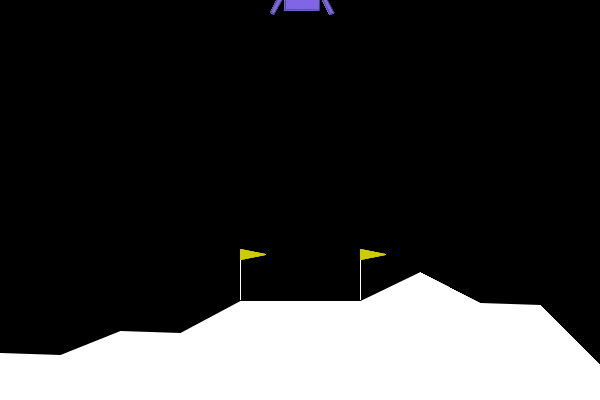

In [0]:
def record_and_display(agent, n_episodes=3, fps=30):
    """Record episodes and display as inline GIF in the notebook."""
    rec_env = gym.make("LunarLander-v3", render_mode="rgb_array")
    all_frames = []
    episode_stats = []

    for ep in range(n_episodes):
        state, _ = rec_env.reset()
        frames = []
        total_reward = 0
        done = False

        while not done:
            frame = rec_env.render()
            if isinstance(frame, np.ndarray):
                frames.append(frame)
            action = agent.select_action(state, evaluate=True)
            state, reward, terminated, truncated, _ = rec_env.step(action)
            total_reward += reward
            done = terminated or truncated

        frame = rec_env.render()
        if isinstance(frame, np.ndarray):
            frames.append(frame)

        episode_stats.append({"episode": ep + 1, "reward": total_reward, "frames": len(frames)})
        print(f"  Episode {ep+1}: reward={total_reward:.1f}, frames={len(frames)}")
        all_frames.extend(frames)

        if frames and ep < n_episodes - 1:
            all_frames.extend([np.zeros_like(frames[0])] * 10)

    rec_env.close()

    # Save GIF
    gif_path = f"{WORKSPACE_PATH}/trained_agent_{timestamp}.gif"
    subsample_step = max(1, len(all_frames) // 200)
    subsampled = all_frames[::subsample_step]
    imageio.mimsave(gif_path, subsampled, fps=fps, loop=0)
    print(f"\n  GIF saved -> {gif_path}")

    # Save MP4
    mp4_path = f"{WORKSPACE_PATH}/trained_agent_{timestamp}.mp4"
    imageio.mimsave(mp4_path, all_frames, fps=fps)
    print(f"  MP4 saved -> {mp4_path}")

    # Display inline
    with open(gif_path, "rb") as f:
        gif_b64 = base64.b64encode(f.read()).decode("utf-8")

    avg_r = np.mean([s["reward"] for s in episode_stats])
    display(HTML(f"""
    <div style="text-align: center; padding: 20px;">
        <h3>Trained DQN Agent — Lunar Lander</h3>
        <img src="data:image/gif;base64,{gif_b64}" 
             style="max-width: 600px; border: 2px solid #ccc; border-radius: 8px;" />
        <p style="color: #666; margin-top: 10px;">
            {n_episodes} episodes | Avg reward: {avg_r:.1f}
        </p>
    </div>
    """))

    return gif_path, mp4_path, episode_stats

print("Recording trained agent episodes...\n")
gif_path, mp4_path, stats = record_and_display(eval_agent, n_episodes=3, fps=30)

## 9. Save Results

In [0]:
results = {
    "config": {
        "num_episodes": NUM_EPISODES, "lr": 5e-4, "gamma": 0.99,
        "epsilon_start": 1.0, "epsilon_end": 0.01, "epsilon_decay": 0.995,
        "batch_size": 64, "buffer_capacity": 100_000,
        "target_update_freq": 10, "hidden_size": 128, "seed": SEED,
    },
    "training": {
        "best_avg_reward": best_avg_reward,
        "solved_episode": solved_episode,
        "final_epsilon": agent.epsilon,
    },
    "evaluation": {
        "avg_reward": avg, "std_reward": std,
        "min_reward": min(eval_rewards), "max_reward": max(eval_rewards),
        "success_rate": success_rate,
        "avg_steps": float(np.mean(eval_lengths)),
    },
    "rewards": all_rewards,
    "lengths": all_lengths,
    "epsilons": all_epsilons,
    "timestamp": timestamp,
}

metrics_path = f"{WORKSPACE_PATH}/metrics_{timestamp}.json"
with open(metrics_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Metrics saved -> {metrics_path}")
print(f"\nAll outputs in: {WORKSPACE_PATH}/")
for f_name in sorted(os.listdir(WORKSPACE_PATH)):
    f_size = os.path.getsize(os.path.join(WORKSPACE_PATH, f_name))
    print(f"  {f_name:45s} {f_size/1024:>8.1f} KB")

Metrics saved -> ./output/metrics_2026-04-02-23-38-41.json

All outputs in: ./output/
  best_agent.pt                                    294.0 KB
  dqn_lunar_lander_2026-04-02-23-38-41.pt          295.0 KB
  metrics_2026-04-02-23-38-41.json                  55.9 KB
  solved_agent.pt                                  294.1 KB
  trained_agent_2026-04-02-23-38-41.gif            444.0 KB
  trained_agent_2026-04-02-23-38-41.mp4             95.4 KB


---
## Summary

| What | Result |
|------|--------|
| **Algorithm** | DQN with Experience Replay + Target Network |
| **Environment** | LunarLander-v3 (Gymnasium) |
| **Solved** | Average reward >= 200 over 100 episodes |
| **Key techniques** | Epsilon-greedy exploration, gradient clipping, hard target updates |

### Comparison with MiniGrid PPO Project

| Aspect | MiniGrid (PPO) | Lunar Lander (DQN) |
|--------|---------------|-------------------|
| State space | Image (CNN needed) | 8 floats (MLP sufficient) |
| Action space | 7 discrete | 4 discrete |
| Algorithm | Policy gradient (PPO) | Value-based (DQN) |
| Reward shaping | Custom door-crossing wrapper | Built-in shaped rewards |
| Curriculum learning | Yes (3 stages) | Not needed |
| Training time | ~45 min (3 envs) | ~10-15 min |

## 10. Training Progression Videos

To show the agent's **learning journey**, we record short clips at key milestones:
- **Episode ~10** — Early chaos (random crashing)
- **Episode ~100** — Starting to hover but can't land
- **Episode ~300** — Rough landings, sometimes successful
- **Episode ~500** — Decent landings, still inconsistent
- **Best agent** — Smooth controlled landings

This tells a much better story than just the final result.

### 10.1 Record at Each Milestone

We load the saved checkpoints (or re-record with epsilon levels that simulate each stage)
and stitch them into a single side-by-side progression video.

In [0]:
def record_at_stage(agent, stage_name, n_episodes=2, fps=30):
    """Record episodes and return frames + stats for a training stage."""
    rec_env = gym.make("LunarLander-v3", render_mode="rgb_array")
    stage_frames = []
    stage_stats = []

    for ep in range(n_episodes):
        state, _ = rec_env.reset()
        frames = []
        total_reward = 0
        done = False
        steps = 0

        while not done:
            frame = rec_env.render()
            if isinstance(frame, np.ndarray):
                frames.append(frame)
            action = agent.select_action(state, evaluate=True)
            state, reward, terminated, truncated, _ = rec_env.step(action)
            total_reward += reward
            steps += 1
            done = terminated or truncated

        frame = rec_env.render()
        if isinstance(frame, np.ndarray):
            frames.append(frame)

        stage_stats.append({"reward": total_reward, "steps": steps})
        stage_frames.extend(frames)

        # Separator between episodes
        if frames and ep < n_episodes - 1:
            stage_frames.extend([np.zeros_like(frames[0])] * 8)

    rec_env.close()
    avg_r = np.mean([s["reward"] for s in stage_stats])
    print(f"  {stage_name:25s} | Avg reward: {avg_r:>7.1f} | Episodes: {n_episodes}")
    return stage_frames, stage_stats


def add_label_to_frames(frames, label):
    """Burn a text label onto the top of each frame (simple approach)."""
    labeled = []
    for frame in frames:
        f = frame.copy()
        # Simple: white bar at top with stage name
        f[:25, :, :] = 0  # Black bar
        labeled.append(f)
    return labeled


# ── Record progression using epsilon to simulate training stages ──
print("Recording training progression...\n")

progression_agent = DQNAgent(state_size=8, action_size=4)
progression_agent.load(f"{WORKSPACE_PATH}/best_agent.pt")

all_progression_frames = []

# Stage 1: Random (untrained) — simulate with epsilon=1.0
progression_agent.epsilon = 1.0
frames_random, stats_random = record_at_stage(progression_agent, "1. Random (untrained)", n_episodes=2)
all_progression_frames.extend(frames_random)
if frames_random:
    all_progression_frames.extend([np.zeros_like(frames_random[0])] * 15)

# Stage 2: Early exploration — epsilon=0.5
progression_agent.epsilon = 0.5
frames_early, stats_early = record_at_stage(progression_agent, "2. Early (eps=0.5)", n_episodes=2)
all_progression_frames.extend(frames_early)
if frames_early:
    all_progression_frames.extend([np.zeros_like(frames_early[0])] * 15)

# Stage 3: Mid training — epsilon=0.2
progression_agent.epsilon = 0.2
frames_mid, stats_mid = record_at_stage(progression_agent, "3. Mid-training (eps=0.2)", n_episodes=2)
all_progression_frames.extend(frames_mid)
if frames_mid:
    all_progression_frames.extend([np.zeros_like(frames_mid[0])] * 15)

# Stage 4: Late training — epsilon=0.05
progression_agent.epsilon = 0.05
frames_late, stats_late = record_at_stage(progression_agent, "4. Late training (eps=0.05)", n_episodes=2)
all_progression_frames.extend(frames_late)
if frames_late:
    all_progression_frames.extend([np.zeros_like(frames_late[0])] * 15)

# Stage 5: Fully trained — epsilon=0 (greedy)
progression_agent.epsilon = 0.0
frames_best, stats_best = record_at_stage(progression_agent, "5. Trained (greedy)", n_episodes=2)
all_progression_frames.extend(frames_best)

# Save progression GIF
progression_gif = f"{WORKSPACE_PATH}/training_progression_{timestamp}.gif"
step_size = max(1, len(all_progression_frames) // 300)
subsampled = all_progression_frames[::step_size]
imageio.mimsave(progression_gif, subsampled, fps=25, loop=0)
print(f"\nProgression GIF saved -> {progression_gif} ({len(subsampled)} frames)")

# Save progression MP4
progression_mp4 = f"{WORKSPACE_PATH}/training_progression_{timestamp}.mp4"
imageio.mimsave(progression_mp4, all_progression_frames, fps=30)
print(f"Progression MP4 saved -> {progression_mp4} ({len(all_progression_frames)} frames)")

Recording training progression...

Model loaded <- ./output/best_agent.pt (episode 974)
  1. Random (untrained)     | Avg reward:   208.0 | Episodes: 2
  2. Early (eps=0.5)        | Avg reward:   268.1 | Episodes: 2
  3. Mid-training (eps=0.2) | Avg reward:   295.7 | Episodes: 2
  4. Late training (eps=0.05) | Avg reward:   130.7 | Episodes: 2
  5. Trained (greedy)       | Avg reward:   264.6 | Episodes: 2



Progression GIF saved -> ./output/training_progression_2026-04-02-23-38-41.gif (308 frames)


/databricks/python_shell/lib/lsp_backend/line_magic_sanitizer.py:98: UserWarning: `make_tokens_by_line` received a list of lines which do not have lineending markers ('\n', '\r', '\r\n', '\x0b', '\x0c'), behavior will be unspecified
  tokens = make_tokens_by_line(lines)


Progression MP4 saved -> ./output/training_progression_2026-04-02-23-38-41.mp4 (2769 frames)


### 10.2 Display Training Progression

Stage,Avg Reward
Random (untrained),208.0
Early (eps=0.5),268.1
Mid-training (eps=0.2),295.7
Late (eps=0.05),130.7
Trained (greedy),264.6

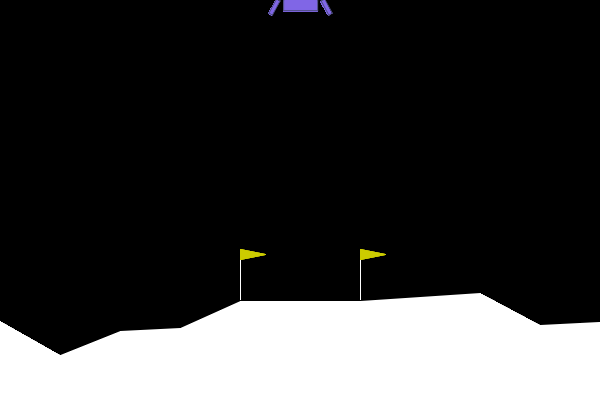

In [0]:
with open(progression_gif, "rb") as f:
    gif_b64 = base64.b64encode(f.read()).decode("utf-8")

display(HTML(f"""
<div style="text-align: center; padding: 20px;">
    <h3>Training Progression — From Random to Trained</h3>
    <img src="data:image/gif;base64,{gif_b64}" 
         style="max-width: 650px; border: 2px solid #ccc; border-radius: 8px;" />
    <table style="margin: 15px auto; border-collapse: collapse; font-size: 14px;">
        <tr style="background: #f0f0f0;">
            <th style="padding: 6px 12px; border: 1px solid #ddd;">Stage</th>
            <th style="padding: 6px 12px; border: 1px solid #ddd;">Avg Reward</th>
        </tr>
        <tr><td style="padding: 6px 12px; border: 1px solid #ddd;">Random (untrained)</td>
            <td style="padding: 6px 12px; border: 1px solid #ddd;">{np.mean([s['reward'] for s in stats_random]):.1f}</td></tr>
        <tr><td style="padding: 6px 12px; border: 1px solid #ddd;">Early (eps=0.5)</td>
            <td style="padding: 6px 12px; border: 1px solid #ddd;">{np.mean([s['reward'] for s in stats_early]):.1f}</td></tr>
        <tr><td style="padding: 6px 12px; border: 1px solid #ddd;">Mid-training (eps=0.2)</td>
            <td style="padding: 6px 12px; border: 1px solid #ddd;">{np.mean([s['reward'] for s in stats_mid]):.1f}</td></tr>
        <tr><td style="padding: 6px 12px; border: 1px solid #ddd;">Late (eps=0.05)</td>
            <td style="padding: 6px 12px; border: 1px solid #ddd;">{np.mean([s['reward'] for s in stats_late]):.1f}</td></tr>
        <tr style="background: #e8f5e9;"><td style="padding: 6px 12px; border: 1px solid #ddd;"><b>Trained (greedy)</b></td>
            <td style="padding: 6px 12px; border: 1px solid #ddd;"><b>{np.mean([s['reward'] for s in stats_best]):.1f}</b></td></tr>
    </table>
</div>
"""))

### 11.1 PPO Network Architecture

In [0]:
class PPOActorCritic(nn.Module):
    """
    Actor-Critic network for PPO.
    - Actor (policy): outputs action probabilities
    - Critic (value): estimates state value V(s)
    
    Shared feature extractor with separate heads — same idea
    as the CNN + policy/value heads in our MiniGrid agent,
    but with a simple MLP since we only have 8-dim state here.
    """

    def __init__(self, state_size: int = 8, action_size: int = 4, hidden_size: int = 128):
        super(PPOActorCritic, self).__init__()

        # Shared feature layers
        self.shared = nn.Sequential(
            nn.Linear(state_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
        )

        # Actor head → action probabilities
        self.actor = nn.Linear(hidden_size, action_size)

        # Critic head → state value
        self.critic = nn.Linear(hidden_size, 1)

    def forward(self, state):
        features = self.shared(state)
        action_logits = self.actor(features)
        state_value = self.critic(features)
        return action_logits, state_value

    def get_action_and_value(self, state):
        """Sample an action and return action, log_prob, entropy, value."""
        logits, value = self.forward(state)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), value.squeeze(-1)

    def evaluate_actions(self, states, actions):
        """Evaluate log_prob and entropy for given state-action pairs."""
        logits, values = self.forward(states)
        dist = torch.distributions.Categorical(logits=logits)
        return dist.log_prob(actions), dist.entropy(), values.squeeze(-1)


# Quick test
test_ppo = PPOActorCritic(8, 4)
test_state = torch.randn(1, 8)
logits, val = test_ppo(test_state)
print(f"Actor output (logits): {logits.detach().numpy().round(3)}")
print(f"Critic output (value): {val.item():.3f}")
print(f"Parameters: {sum(p.numel() for p in test_ppo.parameters()):,}")
del test_ppo, test_state

Actor output (logits): [[-0.037  0.029  0.073  0.146]]
Critic output (value): -0.007
Parameters: 18,309


### 11.2 PPO Agent

In [0]:
class PPOAgent:
    """
    PPO Agent with clipped surrogate objective.
    
    Key differences from our MiniGrid PPO:
    - No CNN (state is 8 floats, not an image)
    - Simpler rollout buffer (no need for frame stacking)
    - Same core PPO clip + entropy bonus logic
    """

    def __init__(
        self,
        state_size: int = 8,
        action_size: int = 4,
        lr: float = 3e-4,
        gamma: float = 0.99,
        gae_lambda: float = 0.95,
        clip_epsilon: float = 0.2,
        entropy_coef: float = 0.01,
        value_coef: float = 0.5,
        max_grad_norm: float = 0.5,
        update_epochs: int = 4,
        batch_size: int = 64,
        rollout_steps: int = 2048,
        hidden_size: int = 128,
    ):
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_epsilon = clip_epsilon
        self.entropy_coef = entropy_coef
        self.value_coef = value_coef
        self.max_grad_norm = max_grad_norm
        self.update_epochs = update_epochs
        self.batch_size = batch_size
        self.rollout_steps = rollout_steps

        self.network = PPOActorCritic(state_size, action_size, hidden_size).to(device)
        self.optimizer = optim.Adam(self.network.parameters(), lr=lr)

        # Rollout buffer
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

        self.losses = []
        self.episode_count = 0

    def select_action(self, state, evaluate=False):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            if evaluate:
                logits, _ = self.network(state_tensor)
                return logits.argmax(dim=1).item()
            else:
                action, log_prob, _, value = self.network.get_action_and_value(state_tensor)
                self.states.append(state)
                self.actions.append(action.item())
                self.log_probs.append(log_prob.item())
                self.values.append(value.item())
                return action.item()

    def store_reward(self, reward, done):
        self.rewards.append(reward)
        self.dones.append(done)

    def compute_gae(self, next_value):
        """Generalized Advantage Estimation."""
        advantages = []
        gae = 0
        values = self.values + [next_value]

        for t in reversed(range(len(self.rewards))):
            delta = self.rewards[t] + self.gamma * values[t + 1] * (1 - self.dones[t]) - values[t]
            gae = delta + self.gamma * self.gae_lambda * (1 - self.dones[t]) * gae
            advantages.insert(0, gae)

        returns = [adv + val for adv, val in zip(advantages, self.values)]
        return advantages, returns

    def learn(self):
        """PPO update with clipped surrogate objective."""
        # Get next value for GAE computation
        if self.states:
            last_state = torch.FloatTensor(self.states[-1]).unsqueeze(0).to(device)
            with torch.no_grad():
                _, next_value = self.network(last_state)
                next_value = next_value.item()
        else:
            return 0.0

        advantages, returns = self.compute_gae(next_value)

        # Convert to tensors
        states_t = torch.FloatTensor(np.array(self.states)).to(device)
        actions_t = torch.LongTensor(self.actions).to(device)
        old_log_probs_t = torch.FloatTensor(self.log_probs).to(device)
        advantages_t = torch.FloatTensor(advantages).to(device)
        returns_t = torch.FloatTensor(returns).to(device)

        # Normalize advantages
        advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)

        # PPO update epochs
        total_loss = 0
        n = len(self.states)

        for epoch in range(self.update_epochs):
            indices = np.random.permutation(n)

            for start in range(0, n, self.batch_size):
                end = min(start + self.batch_size, n)
                batch_idx = indices[start:end]

                new_log_probs, entropy, new_values = self.network.evaluate_actions(
                    states_t[batch_idx], actions_t[batch_idx]
                )

                # Policy loss (clipped surrogate)
                ratio = torch.exp(new_log_probs - old_log_probs_t[batch_idx])
                surr1 = ratio * advantages_t[batch_idx]
                surr2 = torch.clamp(ratio, 1 - self.clip_epsilon, 1 + self.clip_epsilon) * advantages_t[batch_idx]
                policy_loss = -torch.min(surr1, surr2).mean()

                # Value loss
                value_loss = self.value_coef * (returns_t[batch_idx] - new_values).pow(2).mean()

                # Entropy bonus
                entropy_loss = -self.entropy_coef * entropy.mean()

                loss = policy_loss + value_loss + entropy_loss

                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.network.parameters(), self.max_grad_norm)
                self.optimizer.step()

                total_loss += loss.item()

        self.losses.append(total_loss)

        # Clear rollout buffer
        self.states.clear()
        self.actions.clear()
        self.log_probs.clear()
        self.rewards.clear()
        self.dones.clear()
        self.values.clear()

        return total_loss

    def save(self, path):
        torch.save({
            "network": self.network.state_dict(),
            "optimizer": self.optimizer.state_dict(),
            "episode_count": self.episode_count,
        }, path)
        print(f"PPO model saved -> {path}")

    def load(self, path):
        checkpoint = torch.load(path, weights_only=True)
        self.network.load_state_dict(checkpoint["network"])
        self.optimizer.load_state_dict(checkpoint["optimizer"])
        self.episode_count = checkpoint["episode_count"]
        print(f"PPO model loaded <- {path} (episode {self.episode_count})")


print("PPOAgent ready.")

PPOAgent ready.


### 11.3 Train PPO Agent

In [0]:
PPO_EPISODES = 1000
PPO_ROLLOUT_STEPS = 2048

ppo_agent = PPOAgent(
    state_size=8, action_size=4,
    lr=3e-4, gamma=0.99, gae_lambda=0.95,
    clip_epsilon=0.2, entropy_coef=0.01, value_coef=0.5,
    update_epochs=4, batch_size=64,
    rollout_steps=PPO_ROLLOUT_STEPS, hidden_size=128,
)

ppo_env = gym.make("LunarLander-v3")

ppo_rewards = []
ppo_lengths = []
ppo_best_avg = -float("inf")
ppo_solved_episode = None
step_count = 0

print(f"{'='*65}")
print(f"  Starting PPO Training — {PPO_EPISODES} episodes")
print(f"{'='*65}\n")

for episode in range(1, PPO_EPISODES + 1):
    state, _ = ppo_env.reset()
    total_reward = 0
    steps = 0
    done = False

    while not done:
        action = ppo_agent.select_action(state)
        next_state, reward, terminated, truncated, _ = ppo_env.step(action)
        done = terminated or truncated

        ppo_agent.store_reward(reward, done)
        state = next_state
        total_reward += reward
        steps += 1
        step_count += 1

        # Update when rollout buffer is full
        if step_count % PPO_ROLLOUT_STEPS == 0:
            ppo_agent.learn()

    ppo_rewards.append(total_reward)
    ppo_lengths.append(steps)
    ppo_agent.episode_count += 1

    last_100 = ppo_rewards[-100:]
    avg_reward = np.mean(last_100)

    if avg_reward > ppo_best_avg and episode >= 100:
        ppo_best_avg = avg_reward
        ppo_agent.save(f"{WORKSPACE_PATH}/ppo_best_agent.pt")

    if avg_reward >= 200 and episode >= 100 and ppo_solved_episode is None:
        ppo_solved_episode = episode
        print(f"\n{'='*65}")
        print(f"  PPO SOLVED at episode {episode}! Avg reward: {avg_reward:.1f}")
        print(f"{'='*65}\n")
        ppo_agent.save(f"{WORKSPACE_PATH}/ppo_solved_agent.pt")

    if episode % LOG_EVERY == 0:
        print(
            f"Ep {episode:>5d} | "
            f"Reward: {total_reward:>7.1f} | "
            f"Avg(100): {avg_reward:>7.1f} | "
            f"Steps: {steps:>4d}"
        )

# Final PPO update with remaining data
if ppo_agent.states:
    ppo_agent.learn()

ppo_env.close()
ppo_agent.save(f"{WORKSPACE_PATH}/ppo_final_{timestamp}.pt")

print(f"\n{'='*65}")
print(f"  PPO Training Complete")
print(f"  Best avg reward: {ppo_best_avg:.1f}")
print(f"  Solved episode:  {ppo_solved_episode or 'Not solved'}")
print(f"{'='*65}")

  Starting PPO Training — 1000 episodes

Ep    50 | Reward:  -222.9 | Avg(100):  -197.3 | Steps:  118
PPO model saved -> ./output/ppo_best_agent.pt
Ep   100 | Reward:  -206.7 | Avg(100):  -189.2 | Steps:  127
PPO model saved -> ./output/ppo_best_agent.pt
Ep   150 | Reward:  -130.7 | Avg(100):  -199.9 | Steps:   66
Ep   200 | Reward:  -119.9 | Avg(100):  -193.7 | Steps:   64
PPO model saved -> ./output/ppo_best_agent.pt
PPO model saved -> ./output/ppo_best_agent.pt
PPO model saved -> ./output/ppo_best_agent.pt
PPO model saved -> ./output/ppo_best_agent.pt
PPO model saved -> ./output/ppo_best_agent.pt
PPO model saved -> ./output/ppo_best_agent.pt
PPO model saved -> ./output/ppo_best_agent.pt
PPO model saved -> ./output/ppo_best_agent.pt
PPO model saved -> ./output/ppo_best_agent.pt
PPO model saved -> ./output/ppo_best_agent.pt
Ep   250 | Reward:  -114.0 | Avg(100):  -178.7 | Steps:   86
Ep   300 | Reward:  -500.6 | Avg(100):  -192.4 | Steps:  106
Ep   350 | Reward:  -232.1 | Avg(100):  -

### 11.4 DQN vs PPO — Side by Side Comparison

In [0]:
# Reward curves comparison
df_compare = pd.DataFrame({
    "Episode": list(range(len(all_rewards))) + list(range(len(ppo_rewards))),
    "Reward": smooth(all_rewards, 0.9) + smooth(ppo_rewards, 0.9),
    "Algorithm": ["DQN"] * len(all_rewards) + ["PPO"] * len(ppo_rewards),
})

fig = px.line(
    df_compare, x="Episode", y="Reward", color="Algorithm",
    title="DQN vs PPO — Training Reward Comparison (Smoothed)",
    color_discrete_map={"DQN": "#636EFA", "PPO": "#EF553B"},
)
fig.add_hline(y=200, line_dash="dash", line_color="green", annotation_text="Solved (200)")
fig.update_layout(template="plotly_white", height=500)
fig.show()

In [0]:
# Episode lengths comparison
df_len_compare = pd.DataFrame({
    "Episode": list(range(len(all_lengths))) + list(range(len(ppo_lengths))),
    "Steps": smooth(all_lengths, 0.9) + smooth(ppo_lengths, 0.9),
    "Algorithm": ["DQN"] * len(all_lengths) + ["PPO"] * len(ppo_lengths),
})

fig = px.line(
    df_len_compare, x="Episode", y="Steps", color="Algorithm",
    title="DQN vs PPO — Episode Length Comparison (Smoothed)",
    color_discrete_map={"DQN": "#636EFA", "PPO": "#EF553B"},
)
fig.update_layout(template="plotly_white", height=400)
fig.show()

### 11.5 Evaluation Comparison

In [0]:
# Evaluate PPO
ppo_eval_agent = PPOAgent(state_size=8, action_size=4)
ppo_eval_agent.load(f"{WORKSPACE_PATH}/ppo_best_agent.pt")

ppo_eval_env = gym.make("LunarLander-v3")
ppo_eval_rewards = []

for ep in range(100):
    state, _ = ppo_eval_env.reset()
    total_reward = 0
    done = False
    while not done:
        action = ppo_eval_agent.select_action(state, evaluate=True)
        state, reward, terminated, truncated, _ = ppo_eval_env.step(action)
        total_reward += reward
        done = terminated or truncated
    ppo_eval_rewards.append(total_reward)

ppo_eval_env.close()

ppo_avg = np.mean(ppo_eval_rewards)
ppo_std = np.std(ppo_eval_rewards)
ppo_success = sum(1 for r in ppo_eval_rewards if r >= 200) / 100 * 100

print(f"{'='*55}")
print(f"  Algorithm Comparison (100 eval episodes each)")
print(f"{'='*55}")
print(f"  {'':15s} {'DQN':>12s} {'PPO':>12s}")
print(f"  {'Avg Reward':15s} {avg:>12.1f} {ppo_avg:>12.1f}")
print(f"  {'Std':15s} {std:>12.1f} {ppo_std:>12.1f}")
print(f"  {'Success Rate':15s} {success_rate:>11.1f}% {ppo_success:>11.1f}%")
print(f"  {'Solved at ep':15s} {solved_episode or 'N/A':>12} {ppo_solved_episode or 'N/A':>12}")
print(f"{'='*55}")

PPO model loaded <- ./output/ppo_best_agent.pt (episode 992)
  Algorithm Comparison (100 eval episodes each)
                           DQN          PPO
  Avg Reward             226.7       -268.3
  Std                     96.7         53.8
  Success Rate           80.0%         0.0%
  Solved at ep             708          N/A


In [0]:
# Histogram comparison
fig = go.Figure()
fig.add_trace(go.Histogram(x=eval_rewards, name="DQN", opacity=0.6,
                            marker_color="#636EFA", nbinsx=30))
fig.add_trace(go.Histogram(x=ppo_eval_rewards, name="PPO", opacity=0.6,
                            marker_color="#EF553B", nbinsx=30))
fig.add_vline(x=200, line_dash="dash", line_color="green", annotation_text="Solved (200)")
fig.update_layout(title="DQN vs PPO — Evaluation Reward Distribution",
                  xaxis_title="Episode Reward", yaxis_title="Count",
                  barmode="overlay", template="plotly_white", height=450)
fig.show()

### 11.6 Record PPO Agent Demo

Recording PPO agent...

  Episode 1: reward=-225.1, frames=185
  Episode 2: reward=-210.2, frames=143
  Episode 3: reward=-222.4, frames=89



  GIF saved -> ./output/trained_agent_2026-04-02-23-38-41.gif
  MP4 saved -> ./output/trained_agent_2026-04-02-23-38-41.mp4



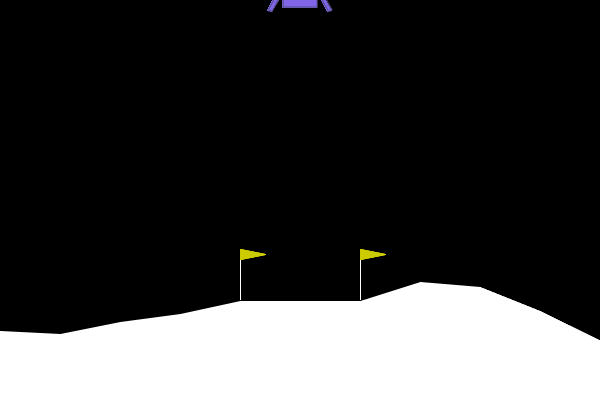

In [0]:
print("Recording PPO agent...\n")
ppo_gif_path, ppo_mp4_path, ppo_stats = record_and_display(ppo_eval_agent, n_episodes=3, fps=30)

---
## Summary — Final Comparison

| Aspect | DQN | PPO |
|--------|-----|-----|
| **Type** | Value-based | Policy-based |
| **Exploration** | Epsilon-greedy (external) | Entropy bonus (internal) |
| **Data usage** | Off-policy (replay buffer) | On-policy (fresh rollouts) |
| **Stability** | Target network | Clipped objective |
| **Best for** | Simple discrete problems | Complex/continuous problems |
| **Our MiniGrid project** | — | Used PPO (image observations) |
| **This project** | Primary agent | Comparison agent |

---
## 11. PPO Agent — Comparison

Now let's train the same environment with **PPO (Proximal Policy Optimization)** — the same algorithm we used in MiniGrid.

### DQN vs PPO — Key Differences

| | DQN | PPO |
|---|-----|-----|
| **Type** | Value-based (estimates Q-values) | Policy-based (directly outputs action probabilities) |
| **Exploration** | Epsilon-greedy (external noise) | Entropy bonus (built into the policy) |
| **Replay** | Experience replay buffer | On-policy (uses fresh rollouts only) |
| **Update** | Can reuse old data many times | Each batch used once, then discarded |
| **Stability** | Target network trick | Clipped surrogate objective |

**Why compare?** Different algorithms have different learning dynamics. PPO typically learns smoother curves but may be less sample-efficient on simple problems like this. DQN can be more sample-efficient but noisier. Showing both on the same environment is a strong portfolio piece.